In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv("logistic_regression_credit_default.csv")

In [3]:
df.head(10)

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Type,Annual_Income,Monthly_Debt,Credit_Score,Credit_History_Years,...,Dependents,Years_at_Current_Job,Region,Monthly_Expenses,Debt_to_Income_Ratio,Utilization_Rate,Recent_Credit_Inquiries,Has_CoSigner,Previous_Default,Default
0,CUST-000001,30,Female,Single,Master,Salaried,51381.72,642.12,662.0,9.5,...,1,0.7,North,1549.55,0.1500,0.4865,2,No,0,0
1,CUST-000002,58,Male,Married,Bachelor,Salaried,53626.86,1727.29,705.0,37.6,...,2,NaN,North,2225.68,0.3865,0.4578,1,No,0,0
2,CUST-000003,42,Female,Married,High School,Salaried,19289.48,945.95,635.0,17.8,...,2,2.4,South,1017.09,0.5885,0.1824,1,Yes,0,1
3,CUST-000004,37,Male,Single,NaN,Unemployed,19593.81,848.40,NaN,17.2,...,1,1.5,West,698.54,0.5196,0.7927,2,Yes,0,1
4,CUST-000005,53,Female,Single,Associate,Unemployed,8558.69,364.94,753.0,30.1,...,0,2.6,South,350.00,0.5117,0.6196,1,No,0,1
5,CUST-000006,48,Male,Married,High School,Self-employed,16499.47,654.68,687.0,27.6,...,1,10.4,East,587.38,0.4761,0.5509,1,No,0,0
6,CUST-000007,19,Female,Married,Bachelor,Contract,75576.03,1375.52,775.0,0.0,...,2,0.5,West,2855.31,0.2184,0.3321,2,No,0,0
7,CUST-000008,39,Male,Single,High School,Self-employed,277778.25,1575.20,748.0,18.9,...,0,5.3,East,1867.64,0.3938,0.1764,3,No,0,0
8,CUST-000009,62,Female,Single,High School,Unemployed,14605.69,837.03,644.0,42.2,...,0,3.0,West,522.60,0.6877,0.4441,2,No,0,1
9,CUST-000010,44,Male,Divorced,Bachelor,Salaried,32175.86,426.27,714.0,21.0,...,0,10.7,East,730.31,0.1590,0.4779,1,No,0,0


In [4]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education_Level',
       'Employment_Type', 'Annual_Income', 'Monthly_Debt', 'Credit_Score',
       'Credit_History_Years', 'Num_Credit_Cards', 'Num_Late_Payments',
       'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Existing_Loans',
       'Savings_Balance', 'Checking_Balance', 'Home_Ownership', 'Dependents',
       'Years_at_Current_Job', 'Region', 'Monthly_Expenses',
       'Debt_to_Income_Ratio', 'Utilization_Rate', 'Recent_Credit_Inquiries',
       'Has_CoSigner', 'Previous_Default', 'Default'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              5000 non-null   object 
 1   Age                      5000 non-null   int64  
 2   Gender                   5000 non-null   object 
 3   Marital_Status           5000 non-null   object 
 4   Education_Level          4932 non-null   object 
 5   Employment_Type          4920 non-null   object 
 6   Annual_Income            4885 non-null   float64
 7   Monthly_Debt             5000 non-null   float64
 8   Credit_Score             4908 non-null   float64
 9   Credit_History_Years     5000 non-null   float64
 10  Num_Credit_Cards         5000 non-null   int64  
 11  Num_Late_Payments        5000 non-null   int64  
 12  Loan_Amount              5000 non-null   float64
 13  Loan_Term_Months         5000 non-null   int64  
 14  Interest_Rate           

In [6]:
df.isnull().sum()

Customer_ID                  0
Age                          0
Gender                       0
Marital_Status               0
Education_Level             68
Employment_Type             80
Annual_Income              115
Monthly_Debt                 0
Credit_Score                92
Credit_History_Years         0
Num_Credit_Cards             0
Num_Late_Payments            0
Loan_Amount                  0
Loan_Term_Months             0
Interest_Rate                0
Existing_Loans               0
Savings_Balance            143
Checking_Balance           114
Home_Ownership              51
Dependents                   0
Years_at_Current_Job       109
Region                       0
Monthly_Expenses             0
Debt_to_Income_Ratio         0
Utilization_Rate            85
Recent_Credit_Inquiries      0
Has_CoSigner                 0
Previous_Default             0
Default                      0
dtype: int64

In [7]:
df.dropna()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Type,Annual_Income,Monthly_Debt,Credit_Score,Credit_History_Years,...,Dependents,Years_at_Current_Job,Region,Monthly_Expenses,Debt_to_Income_Ratio,Utilization_Rate,Recent_Credit_Inquiries,Has_CoSigner,Previous_Default,Default
2,CUST-000003,42,Female,Married,High School,Salaried,19289.48,945.95,635.0,17.8,...,2,2.4,South,1017.09,0.5885,0.1824,1,Yes,0,1
4,CUST-000005,53,Female,Single,Associate,Unemployed,8558.69,364.94,753.0,30.1,...,0,2.6,South,350.00,0.5117,0.6196,1,No,0,1
5,CUST-000006,48,Male,Married,High School,Self-employed,16499.47,654.68,687.0,27.6,...,1,10.4,East,587.38,0.4761,0.5509,1,No,0,0
6,CUST-000007,19,Female,Married,Bachelor,Contract,75576.03,1375.52,775.0,0.0,...,2,0.5,West,2855.31,0.2184,0.3321,2,No,0,0
7,CUST-000008,39,Male,Single,High School,Self-employed,277778.25,1575.20,748.0,18.9,...,0,5.3,East,1867.64,0.3938,0.1764,3,No,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,CUST-004995,44,Male,Single,Bachelor,Contract,30454.71,251.17,531.0,21.2,...,0,15.3,West,1223.21,0.0990,0.4789,2,No,1,1
4995,CUST-004996,35,Female,Divorced,High School,Retired,53590.34,1001.53,638.0,15.3,...,0,11.4,South,2324.06,0.2243,0.4504,0,No,0,1
4996,CUST-004997,52,Male,Single,Master,Self-employed,111725.70,3800.74,722.0,30.2,...,0,12.9,North,6239.02,0.4082,0.6875,0,No,0,0
4997,CUST-004998,38,Male,Married,High School,Retired,29381.86,1032.85,755.0,18.5,...,2,8.0,North,1855.28,0.4218,0.4372,2,No,0,0


In [12]:
df.drop("Customer_ID",inplace=True,axis=1)

In [13]:
numeric_df = df.select_dtypes(include="number")

In [14]:
corr= numeric_df.corr()

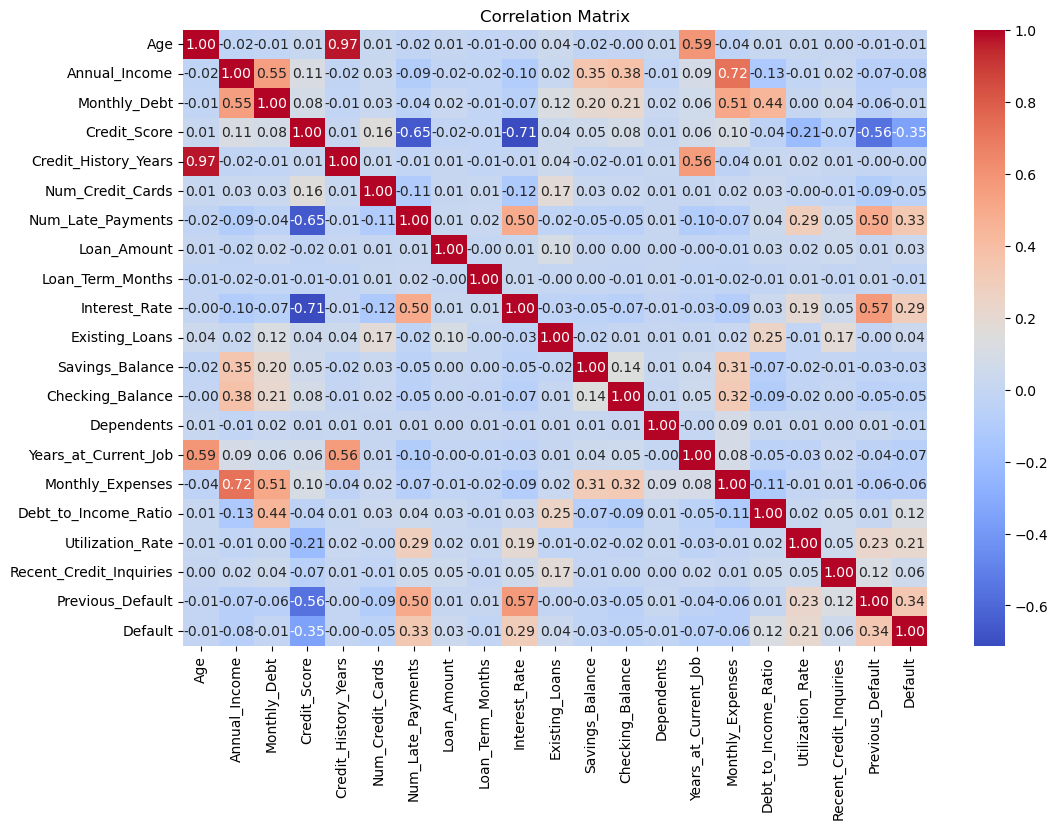

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.compose import ColumnTransformer

In [17]:
X = df.drop(columns=["Default"])
y= df["Default"]

In [24]:
numeric_columns = X.select_dtypes(include="number").columns
categorical_columns = X.select_dtypes(include=["category","string","object"]).columns

In [25]:
numeric_pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("impute",SimpleImputer(strategy="median"))
])

In [31]:
categoric_pipeline =Pipeline([
    ("encoder",OneHotEncoder(handle_unknown="ignore")),
    ("impute",SimpleImputer(strategy="most_frequent"))
])

In [32]:
preprocessor = ColumnTransformer([
    ("numeric",numeric_pipeline,numeric_columns),
    ("categoric",categoric_pipeline,categorical_columns)
])

In [33]:
model_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("logistic",LogisticRegression(max_iter=200,class_weight="balanced",random_state=15))
])

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [35]:
model_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('logistic', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred = model_pipeline.predict(X_test)

In [37]:
score = accuracy_score(y_pred,y_test)
print("Accuracy : ",score)
print(classification_report(y_pred,y_test))
print("Confusion Matrix : ",confusion_matrix(y_pred,y_test))

Accuracy :  0.7136
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       860
           1       0.57      0.34      0.43       390

    accuracy                           0.71      1250
   macro avg       0.66      0.61      0.62      1250
weighted avg       0.69      0.71      0.69      1250

Confusion Matrix :  [[759 101]
 [257 133]]
